In [1]:
import mysql.connector

DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "Fan65101265",
    "database": "appstore_reviews"
}

conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

cursor.execute("SET FOREIGN_KEY_CHECKS = 0")
cursor.execute("DROP TABLE IF EXISTS cleaned_reviews")
cursor.execute("DROP TABLE IF EXISTS raw_reviews")
cursor.execute("DROP TABLE IF EXISTS Country")
cursor.execute("DROP TABLE IF EXISTS App")
cursor.execute("SET FOREIGN_KEY_CHECKS = 1")

conn.commit()
cursor.close()
conn.close()

print("✅ Database clean.")

✅ Database clean.


In [2]:
# Cell 1: Install dependencies and import libraries
!pip install requests
!pip install langdetect
!pip install mysql-connector-python

import requests
import pandas as pd
import matplotlib.pyplot as plt
import re
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
import mysql.connector

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 2: Configuration parameters - app list, country list, page range
# MODIFIED: Auto-detect pages based on existing data

apps = {
    "YouTube": 544007664,
    "Monopoly GO": 1621328561,
    "Candy Crush": 553834731,
    "ChatGPT": 6448311069,
    "Spotify": 324684580
}

countries = ["us", "gb", "au", "ca", "in"]

# ============================================================
# MODIFIED: Auto-detect number of pages to fetch
# First run: fetch 9 pages (full historical data)
# Subsequent runs: fetch only 3 pages (latest reviews)
# ============================================================
def get_existing_review_count():
    try:
        conn = mysql.connector.connect(**DB_CONFIG)
        cursor = conn.cursor()
        cursor.execute("SELECT COUNT(*) FROM raw_reviews")
        count = cursor.fetchone()[0]
        cursor.close()
        conn.close()
        return count
    except:
        return 0

existing_count = get_existing_review_count()

if existing_count == 0:
    pages = range(1, 10)
    print(f"First run: fetching 9 pages per app/country")
else:
    pages = range(1, 4)
    print(f"Existing data found ({existing_count} records): fetching 3 latest pages")
# ============================================================
# END MODIFIED
# ============================================================

region_map = {
    "us": "North America",
    "ca": "North America",
    "in": "Asia Pacific",
    "au": "Asia Pacific",
    "gb": "Europe"
}

app_category_map = {
    'ChatGPT': 'AI Assistant',
    'YouTube': 'Video',
    'Candy Crush': 'Gaming',
    'Spotify': 'Gaming',
    'Monopoly GO': 'Gaming'
}

print("Configuration loaded!")
pages = range(1, 10)
print(f"pages force to ingest 9 pages: {list(pages)}")

First run: fetching 9 pages per app/country
Configuration loaded!
pages force to ingest 9 pages: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
# Cell 3: Define data scraping function
def get_reviews(app_id, country, page=1):
    """
    Fetch review data from Apple App Store RSS feed
    
    Parameters:
    -----------
    app_id : int/str
        The App Store ID of the application
    country : str
        Country code (us, gb, in, au, ca)
    page : int
        Page number, starting from 1
    
    Returns:
    --------
    pd.DataFrame
        DataFrame containing review data
    """
    url = f"https://itunes.apple.com/{country}/rss/customerreviews/page={page}/id={app_id}/sortby=mostrecent/json"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
    except Exception as e:
        print(f"Error fetching data for app {app_id}, country {country}, page {page}: {e}")
        return pd.DataFrame()
    
    entries = data["feed"].get("entry", [])
    
    # Handle case where first entry is metadata
    if isinstance(entries, dict):
        entries = [entries]
    if len(entries) > 1:
        entries = entries[1:]
    
    reviews = []
    for review in entries:
        try:
            reviews.append({
                "review_id": review["id"]["label"],
                "author": review["author"]["name"]["label"],
                "rating": int(review["im:rating"]["label"]),
                "version": review["im:version"]["label"],
                "title": review["title"]["label"],
                "content": review["content"]["label"],
                "date": review["updated"]["label"]
            })
        except KeyError as e:
            print(f"Missing field in review: {e}")
            continue
    
    return pd.DataFrame(reviews)

In [38]:
# Cell 4: Batch collect data for all apps, countries, and pages
print("Starting data collection...")
final_df = []

for app_name, app_id in apps.items():
    for country in countries:
        for page in pages:
            print(f"Fetching: {app_name} | {country} | Page {page}")
            
            df = get_reviews(app_id, country, page)
            
            if len(df) == 0:
                print(f"  No data for {app_name} | {country} | Page {page}")
                continue
            
            # Add metadata columns
            df["app_name"] = app_name
            df["app_id"] = app_id
            df["country_name"] = country
            df["region"] = df["country_name"].map(region_map)
            df["app_category"] = df["app_name"].map(app_category_map)
            
            final_df.append(df)

print(f"\nData collection completed! Total DataFrames collected: {len(final_df)}")

Starting data collection...
Fetching: YouTube | us | Page 1
Fetching: YouTube | us | Page 2
Fetching: YouTube | us | Page 3
Fetching: YouTube | us | Page 4
Fetching: YouTube | us | Page 5
Fetching: YouTube | us | Page 6
Fetching: YouTube | us | Page 7
Fetching: YouTube | us | Page 8
Fetching: YouTube | us | Page 9
Fetching: YouTube | gb | Page 1
Fetching: YouTube | gb | Page 2
Fetching: YouTube | gb | Page 3
Fetching: YouTube | gb | Page 4
Fetching: YouTube | gb | Page 5
Fetching: YouTube | gb | Page 6
Fetching: YouTube | gb | Page 7
Fetching: YouTube | gb | Page 8
Fetching: YouTube | gb | Page 9
Fetching: YouTube | au | Page 1
Fetching: YouTube | au | Page 2
Fetching: YouTube | au | Page 3
Fetching: YouTube | au | Page 4
Fetching: YouTube | au | Page 5
Fetching: YouTube | au | Page 6
Fetching: YouTube | au | Page 7
Fetching: YouTube | au | Page 8
Fetching: YouTube | au | Page 9
Fetching: YouTube | ca | Page 1
Fetching: YouTube | ca | Page 2
Fetching: YouTube | ca | Page 3
Fetching: Yo

In [39]:
# Cell 5: Merge all data and save raw version
# MODIFIED: Save with timestamp for traceability

from datetime import datetime

if final_df:
    all_reviews = pd.concat(final_df, ignore_index=True)
    print(f"Total records collected: {len(all_reviews)}")
    
    all_reviews = all_reviews.rename(columns={"date": "review_date"})

    # Generate stable business key

    
    all_reviews["dedup_key"] =(
        all_reviews["app_id"].astype(str)
        + "|"
        + all_reviews["country_name"]
        + "|"
        + all_reviews["review_id"])
    
    # ============================================================
    # MODIFIED: Save with timestamp
    # ============================================================
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    filename_raw = f"Original_Extract_Records_{timestamp}.csv"
    all_reviews.to_csv(filename_raw, index=False, encoding="utf-8-sig")
    print(f"Original data saved: {filename_raw}")
    
    all_reviews.to_csv("Original_Extract_Records_latest.csv", index=False, encoding="utf-8-sig")
    print("Also saved as: Original_Extract_Records_latest.csv")
    # ============================================================
    # END MODIFIED
    # ============================================================
else:
    print("No data collected!")

Total records collected: 10931
Original data saved: Original_Extract_Records_20260719_205914.csv
Also saved as: Original_Extract_Records_latest.csv


In [40]:
# Cell 6: EDA - Basic dataset overview
print("=== Dataset Overview ===")
print(f"Shape: {all_reviews.shape}")
print(f"\nColumns: {all_reviews.columns.tolist()}")
print(f"\nData Types:")
print(all_reviews.dtypes)

print(f"\n=== App Distribution ===")
print(all_reviews['app_name'].value_counts())

print(f"\n=== Country Distribution ===")
print(all_reviews['country_name'].value_counts())

=== Dataset Overview ===
Shape: (10931, 13)

Columns: ['review_id', 'author', 'rating', 'version', 'title', 'content', 'review_date', 'app_name', 'app_id', 'country_name', 'region', 'app_category', 'dedup_key']

Data Types:
review_id       object
author          object
rating           int64
version         object
title           object
content         object
review_date     object
app_name        object
app_id           int64
country_name    object
region          object
app_category    object
dedup_key       object
dtype: object

=== App Distribution ===
app_name
YouTube        2205
Candy Crush    2205
ChatGPT        2205
Spotify        2205
Monopoly GO    2111
Name: count, dtype: int64

=== Country Distribution ===
country_name
us    2205
gb    2205
au    2205
ca    2205
in    2111
Name: count, dtype: int64


In [41]:
# Cell 7: EDA - Check for missing values and duplicates
print("=== Missing Values ===")
print(all_reviews.isna().sum())

# Check for special placeholder values
placeholders = ['unknown', 'n/a', 'na', 'not available', 'none', 'null', '-']
print("\n=== Special Placeholder Values ===")
for col in ['author', 'version', 'title', 'content']:
    count = (all_reviews[col].astype(str).str.strip().str.lower().isin(placeholders).sum())
    print(f"{col}: {count}")

print(f"\n=== Duplicate review_id count: {all_reviews['review_id'].duplicated().sum()}")

=== Missing Values ===
review_id       0
author          0
rating          0
version         0
title           0
content         0
review_date     0
app_name        0
app_id          0
country_name    0
region          0
app_category    0
dedup_key       0
dtype: int64

=== Special Placeholder Values ===
author: 0
version: 0
title: 1
content: 0

=== Duplicate review_id count: 0


In [42]:
# Cell 8: Define text cleaning function
def clean_text(text):
    """
    Clean text: lowercase, remove URLs/emails/numbers/punctuation/emojis, compress whitespace
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'\S+@\S+', '', text)         # Remove email addresses
    text = re.sub(r'\d+', '', text)             # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)         # Remove punctuation
    text = re.sub(r'[^\x00-\x7F]+', '', text)   # Remove emojis and non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()    # Compress multiple spaces
    return text

In [43]:
# Cell 9: Detect review language
def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

all_reviews['review_language'] = all_reviews['content'].apply(detect_language)

print("=== Language Distribution ===")
print(all_reviews['review_language'].value_counts())

=== Language Distribution ===
review_language
en         8947
so          219
fr          179
unknown     158
af          134
es          131
de          123
no           92
ca           86
id           76
it           74
tl           63
sl           60
sw           56
nl           50
da           49
cy           43
ro           40
et           35
sv           33
pl           30
zh-cn        29
pt           28
fi           27
ru           20
sk           19
vi           19
hr           16
tr           15
ar           14
ko           13
hu           10
sq            9
cs            8
lt            4
zh-tw         3
fa            2
ta            2
hi            2
bg            2
te            2
lv            2
pa            1
th            1
gu            1
he            1
el            1
kn            1
ml            1
Name: count, dtype: int64


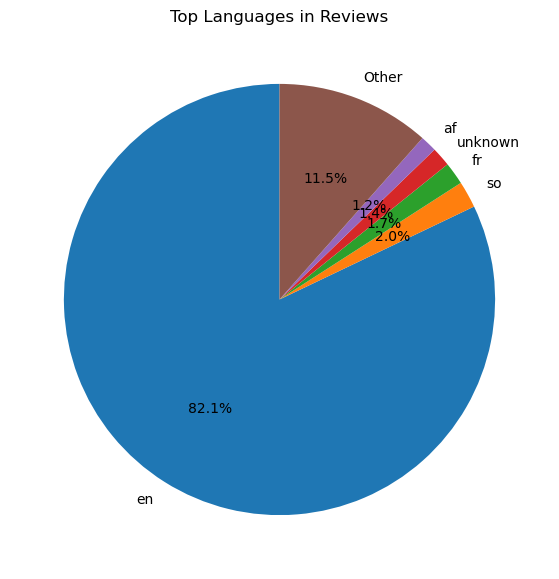

In [11]:
# Cell 10: Language distribution pie chart
lang_counts = all_reviews['review_language'].value_counts()
top5 = lang_counts.head(5)
other = lang_counts.iloc[5:].sum()
lang_summary = pd.concat([top5, pd.Series({'Other': other})])

plt.figure(figsize=(8, 7))
plt.pie(lang_summary, labels=lang_summary.index, autopct='%1.1f%%', startangle=90)
plt.title('Top Languages in Reviews')
plt.show()

In [44]:
# Cell 11: Flag records that should be removed
all_reviews["record_remove_reason"] = None

# 1. Missing content
missing_content = (
    all_reviews["content"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["", "na", "n/a", "unknown"])
)
all_reviews.loc[missing_content, "record_remove_reason"] = "Missing Review Content"

# 2. Duplicate records
duplicated_records = all_reviews['review_id'].duplicated()
all_reviews.loc[duplicated_records & all_reviews["record_remove_reason"].isna(), 
                "record_remove_reason"] = "Duplicated Records"

# 3. Non-English content
non_english = all_reviews['review_language'] != 'en'
all_reviews.loc[non_english & all_reviews["record_remove_reason"].isna(), 
                "record_remove_reason"] = "Non-English Review Content"

# 4. Empty after cleaning
all_reviews["clean_content"] = all_reviews["content"].apply(clean_text)
empty_after_cleaning = all_reviews["clean_content"].str.len() == 0
all_reviews.loc[empty_after_cleaning & all_reviews["record_remove_reason"].isna(), 
                "record_remove_reason"] = "Empty Content After Cleaning"

print("=== Record Remove Reasons ===")
print(all_reviews["record_remove_reason"].value_counts(dropna=False))

=== Record Remove Reasons ===
record_remove_reason
None                          8947
Non-English Review Content    1984
Name: count, dtype: int64


In [45]:
# Cell 12: Generate cleaned dataset
cleaned_reviews = all_reviews.copy()

# Drop duplicate records
cleaned_reviews = cleaned_reviews.drop_duplicates(subset='review_id')

# Filter out flagged records
cleaned_reviews = cleaned_reviews[cleaned_reviews['record_remove_reason'].isna()].copy()

# Add cleaned content column
cleaned_reviews["content_cleaned"] = cleaned_reviews["content"].apply(clean_text)

# Convert date format
cleaned_reviews['date_transformed'] = pd.to_datetime(cleaned_reviews['review_date'])

print(f"Cleaned records: {len(cleaned_reviews)}")
print(f"Original records: {len(all_reviews)}")
print(f"Removed records: {len(all_reviews) - len(cleaned_reviews)}")
print(cleaned_reviews["record_remove_reason"].value_counts(dropna=False))

Cleaned records: 8947
Original records: 10931
Removed records: 1984
record_remove_reason
None    8947
Name: count, dtype: int64


In [46]:
# Cell 13: Save cleaned data
cleaned_reviews.to_csv("cleaned_reviews_2.csv", index=False, encoding="utf-8-sig")
print("cleaned_reviews_2.csv saved successfully!")

# Save raw data with flags
all_reviews.to_csv("raw_reviews_3.csv", index=False, encoding="utf-8-sig")
print("raw_reviews_3.csv saved successfully!")

cleaned_reviews_2.csv saved successfully!
raw_reviews_3.csv saved successfully!


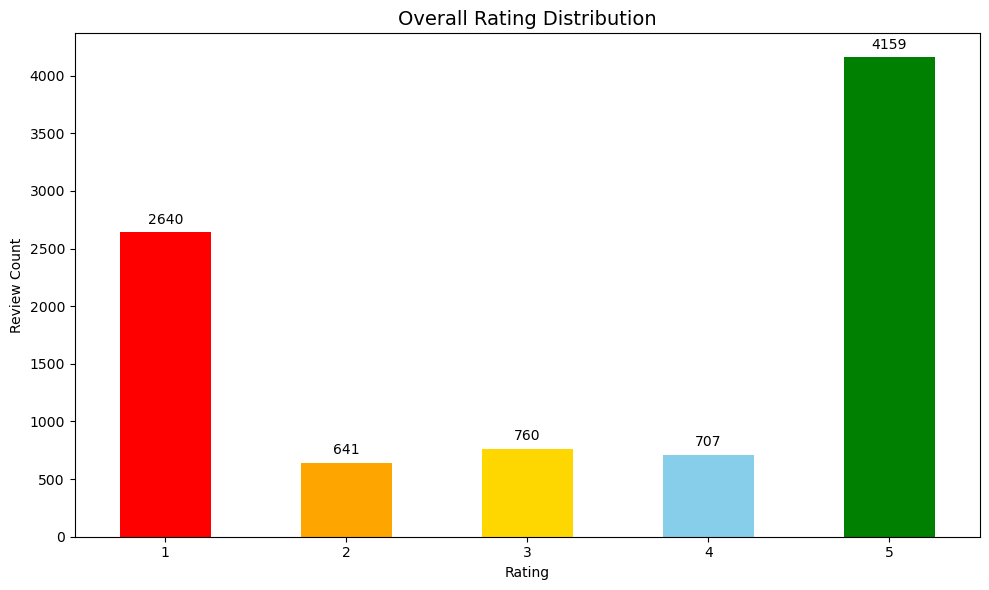

In [116]:
# Cell 14: EDA - Overall rating distribution
plt.figure(figsize=(10, 6))
cleaned_reviews['rating'].value_counts().sort_index().plot(
    kind='bar',
    color=['red', 'orange', 'gold', 'skyblue', 'green']
)
plt.title('Overall Rating Distribution', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Review Count')
plt.xticks(rotation=0)

# Add value labels on top of bars
for i, v in enumerate(cleaned_reviews['rating'].value_counts().sort_index().values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

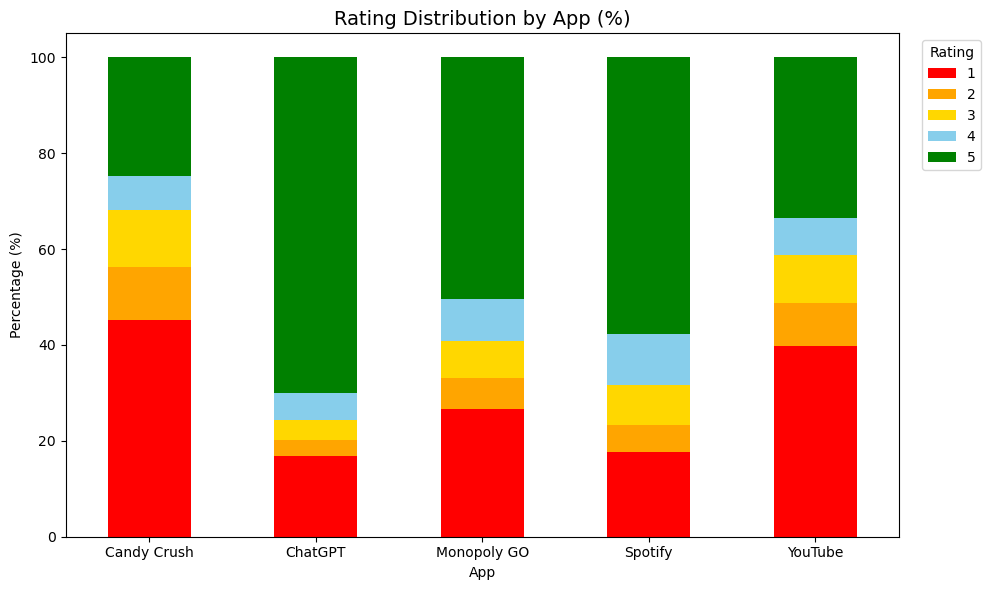

In [117]:
# Cell 15: EDA - Rating distribution by app (stacked percentage chart)
rating_pct = (
    pd.crosstab(
        cleaned_reviews['app_name'],
        cleaned_reviews['rating'],
        normalize='index'
    ) * 100
)

ax = rating_pct.plot(
    kind='bar',
    color=['red', 'orange', 'gold', 'skyblue', 'green'],
    stacked=True,
    figsize=(10, 6)
)

plt.title('Rating Distribution by App (%)', fontsize=14)
plt.xlabel('App')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

=== Word Count Statistics ===
count    8907.000000
mean       28.286853
std        35.473402
min         1.000000
25%         8.000000
50%        17.000000
75%        36.000000
max       592.000000
Name: word_count, dtype: float64


<Figure size 1000x600 with 0 Axes>

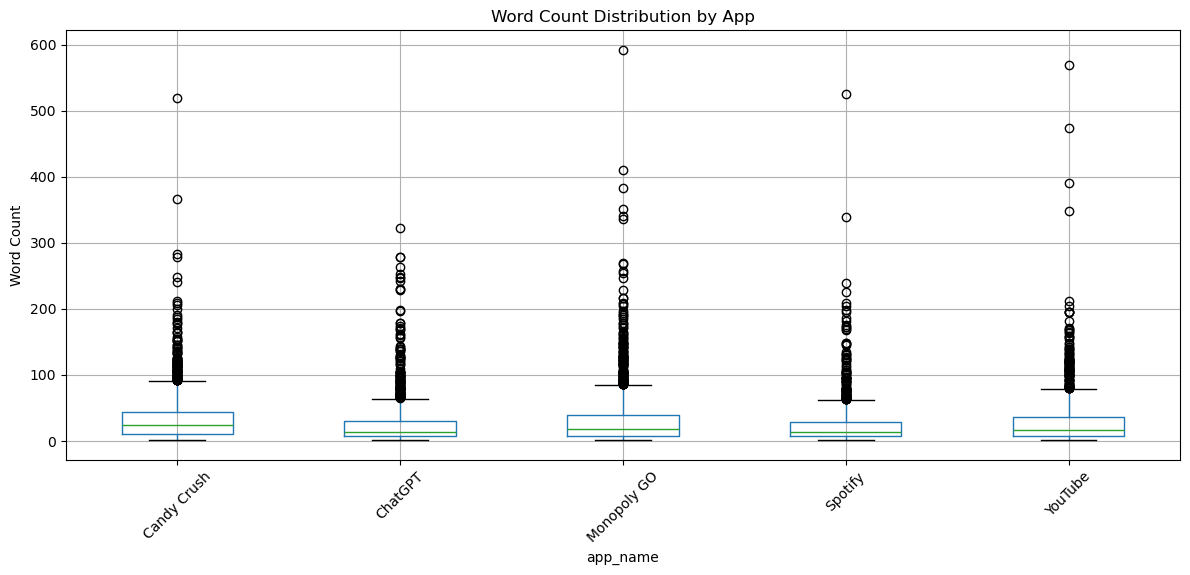

In [118]:
# Cell 16: EDA - Word count statistics
cleaned_reviews['word_count'] = cleaned_reviews['content'].str.split().str.len()

print("=== Word Count Statistics ===")
print(cleaned_reviews['word_count'].describe())

# Boxplot by app
plt.figure(figsize=(10, 6))
cleaned_reviews.boxplot(column='word_count', by='app_name', figsize=(12, 6))
plt.title('Word Count Distribution by App')
plt.suptitle('')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
# Cell 17: Build data warehouse model (Star Schema)
# MODIFIED: Added dedup_key column

# 1. App dimension table
app_mysql = (
    all_reviews[["app_id", "app_name", "app_category"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# 2. Country dimension table
country_mysql = (
    all_reviews[["country_name", "region"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
 # MODIFIED: country_id delete

# 3. Raw reviews fact table - add country_id
raw_reviews_mysql = all_reviews.merge(
    country_mysql,
    on=["country_name", "region"],
    how="left"
)

# Select required columns
raw_reviews_mysql = raw_reviews_mysql[["dedup_key",
    "review_id", "app_id", "author", 
    "rating", "version", "title", "content", 
    "review_date", "review_language", 
    "record_remove_reason"
]].copy()

 



# ============================================================
# END MODIFIED
# ============================================================

# 4. Cleaned reviews fact table
cleaned_reviews_mysql = cleaned_reviews[[
   "dedup_key", "review_id", "content_cleaned", "date_transformed"
]].copy() 





#不应该用python生成的PK 去join
print("=== Data Model Summary ===")
print(f"App dimension: {app_mysql.shape}")
print(f"Country dimension: {country_mysql.shape}")
print(f"Raw fact table: {raw_reviews_mysql.shape}")
print(f"Cleaned fact table: {cleaned_reviews_mysql.shape}")

=== Data Model Summary ===
App dimension: (5, 3)
Country dimension: (5, 2)
Raw fact table: (10931, 11)
Cleaned fact table: (8947, 4)


In [48]:
# Cell 18: Validate data integrity
print("=== Data Integrity Checks ===")
print(f"App PK unique: {app_mysql['app_id'].is_unique}")
print(f"Country PK unique: {country_mysql['country_name'].is_unique}")
print(f"Raw PK unique: {raw_reviews_mysql['dedup_key'].is_unique}")
print(f"Clean PK unique: {cleaned_reviews_mysql['dedup_key'].is_unique}")

print(f"Raw app_id valid: {raw_reviews_mysql['app_id'].isin(app_mysql['app_id']).all()}")
print(f"Clean raw_review_pk valid: {cleaned_reviews_mysql['dedup_key'].isin(raw_reviews_mysql['dedup_key']).all()}")

=== Data Integrity Checks ===
App PK unique: True
Country PK unique: True
Raw PK unique: True
Clean PK unique: True
Raw app_id valid: True
Clean raw_review_pk valid: True


In [49]:
# Cell 19: Export all tables as CSV
app_mysql.to_csv("App.csv", index=False, encoding="utf-8-sig")
country_mysql.to_csv("Country.csv", index=False, encoding="utf-8-sig")
raw_reviews_mysql.to_csv("Raw_Reviews_final.csv", index=False, encoding="utf-8-sig")
cleaned_reviews_mysql.to_csv("Cleaned_Reviews_final.csv", index=False, encoding="utf-8-sig")

print("All CSV files exported successfully!")
print("  - App.csv")
print("  - Country.csv")
print("  - Raw_Reviews_final.csv")
print("  - Cleaned_Reviews_final.csv")

All CSV files exported successfully!
  - App.csv
  - Country.csv
  - Raw_Reviews_final.csv
  - Cleaned_Reviews_final.csv


In [50]:
# Cell 20: MySQL connection configuration
DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "Fan65101265",
    "database": "appstore_reviews"
}

try:
    conn = mysql.connector.connect(
        host=DB_CONFIG["host"],
        user=DB_CONFIG["user"],
        password=DB_CONFIG["password"]
    )
    cursor = conn.cursor()
    cursor.execute("CREATE DATABASE IF NOT EXISTS appstore_reviews")
    print("Database 'appstore_reviews' created/verified!")
    cursor.close()
    conn.close()
except Exception as e:
    print(f"Error: {e}")

Database 'appstore_reviews' created/verified!


In [18]:
# Cell 21: Create database tables
# MODIFIED: Schema optimizations

conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

# 1. App table
# MODIFIED: app_id INT → BIGINT (ChatGPT ID exceeds INT range)
cursor.execute("""
CREATE TABLE IF NOT EXISTS App (
    app_id BIGINT PRIMARY KEY,
    app_name VARCHAR(100) NOT NULL,
    app_category VARCHAR(50)
)
""")

# 2. Country table
# UNCHANGED
cursor.execute("""
CREATE TABLE IF NOT EXISTS Country (
    country_id INT AUTO_INCREMENT PRIMARY KEY, # MODIFIED AUTO_INCREMENT
    country_name VARCHAR(10) NOT NULL,
    region VARCHAR(50)
)
""")

# 3. Raw Reviews table
# MODIFIED: 
#   - raw_review_pk: added AUTO_INCREMENT
#   - review_id: removed UNIQUE constraint
#   - dedup_key: new column
cursor.execute("""
CREATE TABLE IF NOT EXISTS raw_reviews (
    raw_review_pk INT AUTO_INCREMENT PRIMARY KEY,
    review_id VARCHAR(50) NOT NULL,
    app_id BIGINT,
    country_id INT,
    author VARCHAR(255),
    rating INT,
    version VARCHAR(50),
    title VARCHAR(500),
    content TEXT,
    review_date VARCHAR(50),
    review_language VARCHAR(10),
    duplicate_flag BOOLEAN,
    record_remove_reason VARCHAR(100),
    dedup_key VARCHAR(200) UNIQUE,
    FOREIGN KEY (app_id) REFERENCES App(app_id),
    FOREIGN KEY (country_id) REFERENCES Country(country_id)
)
""")

# 4. Cleaned Reviews table
# UNCHANGED
cursor.execute("""
CREATE TABLE IF NOT EXISTS cleaned_reviews (
    clean_review_pk INT AUTO_INCREMENT PRIMARY KEY,
    raw_review_pk INT NOT NULL,
    content_cleaned TEXT,
    date_transformed DATETIME,
    FOREIGN KEY (raw_review_pk) REFERENCES raw_reviews(raw_review_pk)
)
""")

conn.commit()
cursor.close()
conn.close()

print("All tables created successfully!")

All tables created successfully!


In [51]:
# Cell 22: Insert App dimension data
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

sql = """
INSERT INTO App (app_id, app_name, app_category)
VALUES (%s, %s, %s)
"""

inserted = duplicates = errors = 0
for row in app_mysql.itertuples(index=False):
    try:
        cursor.execute(sql, tuple(row))
        inserted += 1
    except mysql.connector.IntegrityError:
        duplicates += 1
    except Exception as e:
        print(f"Error: {e}")
        errors += 1

conn.commit()
cursor.close()
conn.close()

print(f"App table: Inserted={inserted}, Duplicates={duplicates}, Errors={errors}")

App table: Inserted=0, Duplicates=5, Errors=0


In [52]:
# Cell 23: Insert Country dimension data
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

sql = """
INSERT INTO Country (country_name, region)
VALUES (%s, %s)
"""

# Read existing countries
cursor.execute("""
SELECT country_name, region
FROM Country
""")

existing_countries = {
    (row[0], row[1]) for row in cursor.fetchall()
}

inserted = duplicates = errors = 0

for row in country_mysql.itertuples(index=False):

    # Skip existing countries
    if (row.country_name, row.region) in existing_countries:
        duplicates += 1
        continue

    try:
        cursor.execute(sql, tuple(row))
        inserted += 1

        # Update the in-memory set
        existing_countries.add((row.country_name, row.region))

    except mysql.connector.IntegrityError:
        duplicates += 1

    except Exception as e:
        print(f"Error: {e}")
        errors += 1

conn.commit()


cursor.execute("""
SELECT
    country_id,
    country_name,
    region
FROM Country
""")

country_mapping = pd.DataFrame(
    cursor.fetchall(),
    columns=[
        "country_id",
        "country_name",
        "region"
    ]
)

raw_reviews_mysql = all_reviews.merge(
    country_mapping,
    on=["country_name", "region"],
    how="left"
)
raw_reviews_mysql = raw_reviews_mysql[["dedup_key",
    "review_id", "app_id", "country_id","author", 
    "rating", "version", "title", "content", 
    "review_date", "review_language", 
    "record_remove_reason"
]].copy()


cursor.close()
conn.close()

print(f"Country table: Inserted={inserted}, Duplicates={duplicates}, Errors={errors}")

Country table: Inserted=0, Duplicates=5, Errors=0


In [74]:
print(cleaned_reviews_mysql.columns)
print(raw_mapping.columns)

Index(['raw_review_pk', 'content_cleaned', 'date_transformed'], dtype='object')
Index(['raw_review_pk', 'dedup_key'], dtype='object')


In [53]:
# Cell 24: Insert Raw Reviews data
# MODIFIED: Fixed counting logic and filtering

conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

# ============================================================
# MODIFICATION 1: Count records BEFORE insertion
# ============================================================
cursor.execute("SELECT COUNT(*) FROM raw_reviews")
count_before = cursor.fetchone()[0]
print(f"[BEFORE] Raw_Reviews total records: {count_before}")

# ============================================================
# Get existing dedup_keys to avoid duplicates
# ============================================================
cursor.execute("SELECT dedup_key FROM raw_reviews")
existing_keys = {row[0] for row in cursor.fetchall()}

sql = """
INSERT INTO raw_reviews (dedup_key,
    review_id, app_id, country_id, author, rating,
    version, title, content, review_date,
    review_language, record_remove_reason
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

inserted = 0
duplicates = 0
errors = 0

for row in raw_reviews_mysql.itertuples(index=False):
    if row.dedup_key in existing_keys:
        duplicates += 1
        continue
    
    try:
        cursor.execute(sql, tuple(row))
        inserted += 1
        existing_keys.add(row.dedup_key)
    except mysql.connector.IntegrityError:
        duplicates += 1
    except Exception as e:
        print(f"Error: {e}")
        errors += 1

conn.commit()

# ============================================================
# MODIFICATION 2: Count records AFTER insertion
# ============================================================
cursor.execute("SELECT COUNT(*) FROM raw_reviews")
count_after = cursor.fetchone()[0]
print(f"[AFTER] Raw_Reviews total records: {count_after}")
print(f"✅ ACTUAL NEW RECORDS INSERTED: {count_after - count_before}")
print(f"Duplicates (already existed): {duplicates}")
print(f"Errors: {errors}")

# ============================================================
# MODIFICATION 3: Get mapping with record_remove_reason
# ============================================================
mapping_sql = """
SELECT raw_review_pk, dedup_key, record_remove_reason
FROM raw_reviews
"""

cursor.execute(mapping_sql)
raw_mapping = pd.DataFrame(
    cursor.fetchall(),
    columns=["raw_review_pk", "dedup_key", "record_remove_reason"]
)

# Keep only records NOT flagged for removal
raw_mapping_valid = raw_mapping[
    raw_mapping['record_remove_reason'].isna()
].copy()
raw_mapping_valid = raw_mapping_valid[["raw_review_pk", "dedup_key"]]

print(f"Total raw records in DB: {len(raw_mapping)}")
print(f"Valid raw records (not flagged): {len(raw_mapping_valid)}")
print(f"Invalid raw records (flagged): {len(raw_mapping) - len(raw_mapping_valid)}")

# ============================================================
# MODIFICATION 4: Use INNER JOIN to filter out invalid records
# ============================================================
cleaned_reviews_mysql = cleaned_reviews_mysql.merge(
    raw_mapping_valid,
    on="dedup_key",
    how="inner"
)

cleaned_reviews_mysql = cleaned_reviews_mysql.dropna(subset=['raw_review_pk'])

print(f"Cleaned records ready for insertion: {len(cleaned_reviews_mysql)}")

cleaned_reviews_mysql = cleaned_reviews_mysql[
    ["raw_review_pk", "content_cleaned", "date_transformed"]
]

assert cleaned_reviews_mysql["raw_review_pk"].notna().all(), "Found NULL raw_review_pk!"

cursor.close()
conn.close()

print("=" * 60)
print(f"✅ Raw Reviews summary:")
print(f"   - New records inserted: {count_after - count_before}")
print(f"   - Duplicates skipped: {duplicates}")
print(f"   - Total records now: {count_after}")
print("=" * 60)

[BEFORE] Raw_Reviews total records: 10784
[AFTER] Raw_Reviews total records: 10931
✅ ACTUAL NEW RECORDS INSERTED: 147
Duplicates (already existed): 10784
Errors: 0
Total raw records in DB: 10931
Valid raw records (not flagged): 8968
Invalid raw records (flagged): 1963
Cleaned records ready for insertion: 8894
✅ Raw Reviews summary:
   - New records inserted: 147
   - Duplicates skipped: 10784
   - Total records now: 10931


In [54]:
# Cell 25: Insert Cleaned Reviews data
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

# ============================================================
# FIX: Disable strict mode to allow AUTO_INCREMENT
# ============================================================
cursor.execute("SET sql_mode = ''")

sql = """
INSERT INTO cleaned_reviews (
    raw_review_pk,
    content_cleaned,
    date_transformed
)
VALUES (%s, %s, %s)
"""

# Read existing cleaned records
cursor.execute("""
SELECT raw_review_pk
FROM cleaned_reviews
""")

existing_raw_pks = {
    row[0] for row in cursor.fetchall()
}

inserted = 0
duplicates = 0
errors = 0

for row in cleaned_reviews_mysql.itertuples(index=False):

    # Skip existing records
    if row.raw_review_pk in existing_raw_pks:
        duplicates += 1
        continue

    try:
        cursor.execute(sql, (
            row.raw_review_pk,
            row.content_cleaned,
            row.date_transformed
        ))

        inserted += 1

        # Update in-memory set
        existing_raw_pks.add(row.raw_review_pk)

    except mysql.connector.IntegrityError:
        duplicates += 1

    except Exception as e:
        print(f"Error: {e}")
        errors += 1

conn.commit()

cursor.close()
conn.close()

print(f"Cleaned Reviews table: Inserted={inserted}, Duplicates={duplicates}, Errors={errors}")

Cleaned Reviews table: Inserted=115, Duplicates=8779, Errors=0


In [23]:
# Cell 26: Verify data in database
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

tables = ['App', 'Country', 'raw_reviews', 'cleaned_reviews']
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table}: {count} records")

cursor.close()
conn.close()


App: 5 records
Country: 5 records
raw_reviews: 10784 records
cleaned_reviews: 8853 records


In [24]:
# Cell 27: Project summary
print("=" * 60)
print("App Store Reviews ETL Pipeline - Summary")
print("=" * 60)
print(f"\n✅ Data Collected: {len(all_reviews)} raw records")
print(f"✅ Data Cleaned: {len(cleaned_reviews)} valid records")
print(f"✅ Data Removed: {len(all_reviews) - len(cleaned_reviews)} records")
print(f"\n✅ Schema: 4 tables created (2 dimensions, 2 facts)")
print(f"✅ Data Loaded: All data inserted into MySQL")
print("\n📁 Output Files:")
print("   - Original_Extract_Records_1.csv")
print("   - raw_reviews_3.csv")
print("   - cleaned_reviews_2.csv")
print("   - App.csv, Country.csv")
print("   - Raw_Reviews_final.csv, Cleaned_Reviews_final.csv")
print("\n📊 Database: appstore_reviews")
print("=" * 60)
print("🎉 ETL Pipeline completed successfully!")

App Store Reviews ETL Pipeline - Summary

✅ Data Collected: 10784 raw records
✅ Data Cleaned: 8853 valid records
✅ Data Removed: 1931 records

✅ Schema: 4 tables created (2 dimensions, 2 facts)
✅ Data Loaded: All data inserted into MySQL

📁 Output Files:
   - Original_Extract_Records_1.csv
   - raw_reviews_3.csv
   - cleaned_reviews_2.csv
   - App.csv, Country.csv
   - Raw_Reviews_final.csv, Cleaned_Reviews_final.csv

📊 Database: appstore_reviews
🎉 ETL Pipeline completed successfully!


In [25]:
# Cell 28: Validation - verify Raw ↔ Cleaned relationship

print("=" * 60)
print("VALIDATION: Raw_Reviews ↔ Cleaned_Reviews Relationship")
print("=" * 60)

conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

# 1. Count records
cursor.execute("SELECT COUNT(*) FROM raw_reviews")
raw_count = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) FROM cleaned_reviews")
clean_count = cursor.fetchone()[0]

print(f"\n1. Record Counts:")
print(f"   raw_reviews:     {raw_count}")
print(f"   cleaned_reviews: {clean_count}")

# 2. Orphan check
cursor.execute("""
    SELECT COUNT(*) 
    FROM cleaned_reviews c
    LEFT JOIN raw_reviews r ON c.raw_review_pk = r.raw_review_pk
    WHERE r.raw_review_pk IS NULL
""")
orphan_count = cursor.fetchone()[0]

print(f"\n2. Orphan Check:")
print(f"   Orphan records: {orphan_count}")
print(f"   ✅ No orphans" if orphan_count == 0 else f"   ❌ Found {orphan_count} orphans")

# 3. Duplicate dedup_key check
cursor.execute("""
    SELECT dedup_key, COUNT(*) 
    FROM raw_reviews 
    GROUP BY dedup_key 
    HAVING COUNT(*) > 1
""")
dup_keys = cursor.fetchall()

print(f"\n3. Duplicate dedup_key Check:")
print(f"   Duplicate keys: {len(dup_keys)}")
print(f"   ✅ No duplicate dedup_key" if len(dup_keys) == 0 else f"   ❌ Found {len(dup_keys)} duplicate keys")

# 4. PK distribution
cursor.execute("SELECT MIN(raw_review_pk), MAX(raw_review_pk), COUNT(*) FROM raw_reviews")
min_pk, max_pk, total = cursor.fetchone()

print(f"\n4. raw_review_pk Distribution:")
print(f"   MIN: {min_pk}, MAX: {max_pk}, TOTAL: {total}")
print(f"   ✅ PK range matches record count" if max_pk == total else f"   ⚠️ PK gap detected")

cursor.close()
conn.close()

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

VALIDATION: Raw_Reviews ↔ Cleaned_Reviews Relationship

1. Record Counts:
   raw_reviews:     10784
   cleaned_reviews: 8853

2. Orphan Check:
   Orphan records: 0
   ✅ No orphans

3. Duplicate dedup_key Check:
   Duplicate keys: 0
   ✅ No duplicate dedup_key

4. raw_review_pk Distribution:
   MIN: 1, MAX: 10784, TOTAL: 10784
   ✅ PK range matches record count

VALIDATION COMPLETE


In [19]:
# Run this in a new Jupyter Cell
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(**DB_CONFIG)

query = """
SELECT 
    c.clean_review_pk,
    c.raw_review_pk,
    r.dedup_key,
    r.record_remove_reason,
    r.review_language,
    LEFT(r.content, 100) AS content_preview
FROM Cleaned_Reviews c
JOIN Raw_Reviews r ON c.raw_review_pk = r.raw_review_pk
ORDER BY c.clean_review_pk DESC
LIMIT 5;
"""

result = pd.read_sql(query, conn)
conn.close()

print(result)

   clean_review_pk  raw_review_pk                dedup_key  \
0             9558          11730  324684580|5|14254888082   
1             9557          11728  324684580|5|14269711004   
2             9556          11725  324684580|5|14289531297   
3             9555          11722  324684580|5|14307609707   
4             9554          11721  324684580|5|14308566959   

  record_remove_reason review_language  \
0                 None              en   
1                 None              en   
2                 None              en   
3                 None              en   
4                 None              en   

                                     content_preview  
0  Best over any songs all are available and good...  
1  U can do homework listen to my fav songs and m...  
2  Super cool project with good luck in this spac...  
3  If we membership is over we should have to mus...  
4        To much add were played, only for subscribe  


C:\Users\admin\AppData\Local\Temp\ipykernel_13392\3640868695.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, conn)
